In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
#import ydata_profiling # generar reportes en HTML
from ydata_profiling import ProfileReport

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

DIR = "/content/drive/MyDrive/Analítica de datos - UF3 /3.2/3.2.1/Datos"
os.chdir(DIR)

In [ ]:
pkm_path ='Pokemon.csv'
pkm = pd.read_csv(pkm_path, index_col=0)
pkm.head(10)

,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
#,,,,,,,,,,,,
1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
5,Charmeleon,Fire,NaN,405,58,64,58,80,65,80,1,False
6,Charizard,Fire,Flying,534,78,84,78,109,85,100,1,False
6,CharizardMega Charizard X,Fire,Dragon,634,78,130,111,130,85,100,1,False
6,CharizardMega Charizard Y,Fire,Flying,634,78,104,78,159,115,100,1,False


In [ ]:
# Shape del DF
pkm.shape

(800, 12)

In [ ]:
# Registros por columna
pkm.count()

,0
Name,800
Type 1,800
Type 2,414
Total,800
HP,800
Attack,800
Defense,800
Sp. Atk,800
Sp. Def,800
Speed,800


In [ ]:
pkm.describe().T

,count,mean,std,min,25%,50%,75%,max
Total,800.0,435.10250,119.963040,180.0,330.00,450.0,515.0,780.0
HP,800.0,69.25875,25.534669,1.0,50.00,65.0,80.0,255.0
Attack,800.0,79.00125,32.457366,5.0,55.00,75.0,100.0,190.0
Defense,800.0,73.84250,31.183501,5.0,50.00,70.0,90.0,230.0
Sp. Atk,800.0,72.82000,32.722294,10.0,49.75,65.0,95.0,194.0
Sp. Def,800.0,71.90250,27.828916,20.0,50.00,70.0,90.0,230.0
Speed,800.0,68.27750,29.060474,5.0,45.00,65.0,90.0,180.0
Generation,800.0,3.32375,1.661290,1.0,2.00,3.0,5.0,6.0


In [1]:
#profile = ProfileReport(pkm, title="Profiling Report")
#profile.to_notebook_iframe()

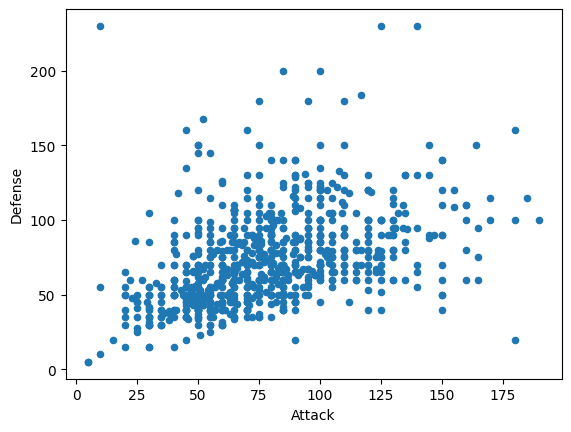

In [ ]:
# Visualizacion de 2 variables numericas
# Forzar graficos para que aparezcan en el notebook
%matplotlib inline
pkm.plot.scatter(x='Attack', y='Defense')
plt.show()

## Hexplot
Una gráfica hexagonal agrega puntos en el espacio en hexágonos y luego colorea esos hexágonos según los valores dentro de ellos.

<Axes: xlabel='Attack', ylabel='Defense'>

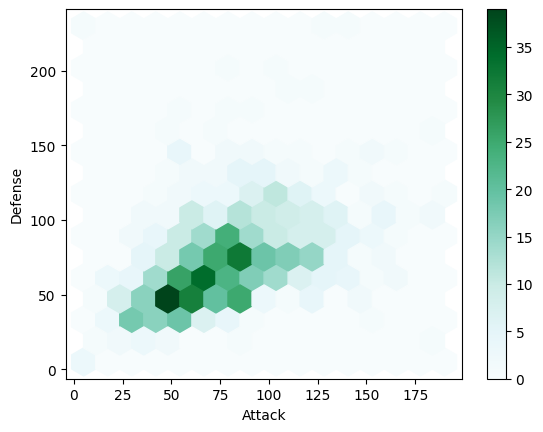

In [ ]:
pkm.plot.hexbin(x='Attack', y='Defense', gridsize=15)

In [ ]:
# Se hace una lista de variables numéricas y otra de categóricas
import numpy as np
num_cols = pkm.select_dtypes(include=np.number).columns.tolist()
cat_cols = pkm.select_dtypes(exclude=np.number).columns.tolist()


8

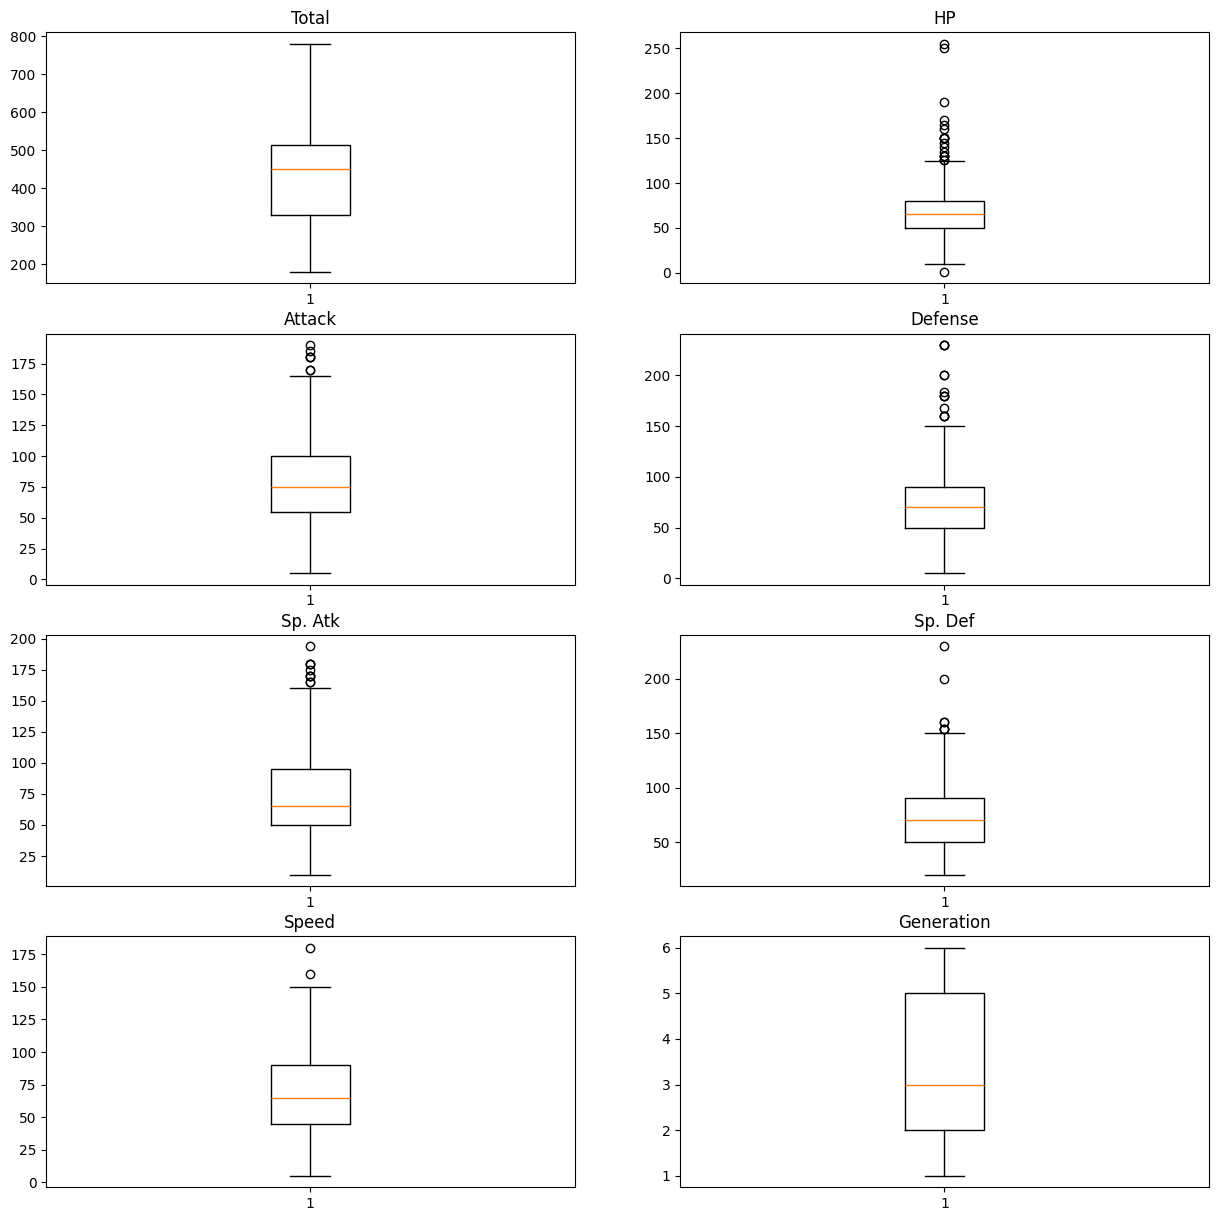

In [ ]:
# Matplotlib
fig, axes = plt.subplots(4,2, figsize=(15,15))
axes = axes.ravel()
for col, ax in zip(pkm[num_cols], axes):
  ax.boxplot(pkm[col])
  ax.set(title=f'{col}', xlabel=None)

Incluir variables nominales en el analisis bivariado.

In [ ]:
pkm_stats_legendary = pkm.groupby(['Legendary', 'Generation']).mean(numeric_only=True)[['Attack', 'Defense']]
pkm_stats_legendary
# Legendary : Nominal
# Generation: Ordinal
# Attack / Defense : Numeric

Attack     Defense
Legendary Generation                        
False     1            74.981250   70.175000
          2            70.693069   72.118812
          3            76.971831   69.901408
          4            79.620370   75.074074
          5            78.246667   70.486667
          6            70.459459   74.013514
True      1           120.833333   89.166667
          2            99.000000   99.000000
          3           118.333333  107.222222
          4           109.846154  103.538462
          5           120.266667   90.733333
          6           125.250000  101.375000

<Axes: xlabel='Legendary,Generation'>

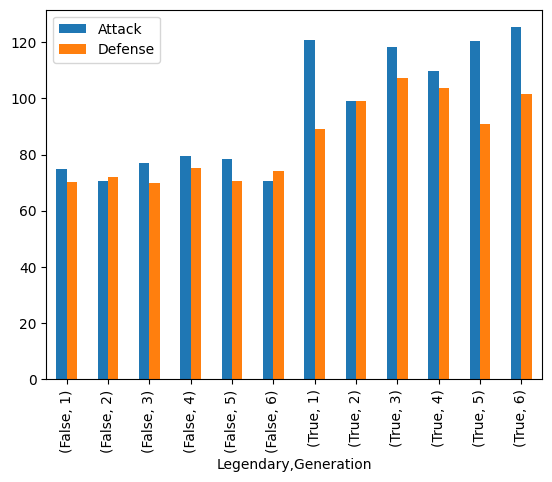

In [ ]:
pkm_stats_legendary.plot.bar(stacked=False)

<Axes: xlabel='Legendary,Generation'>

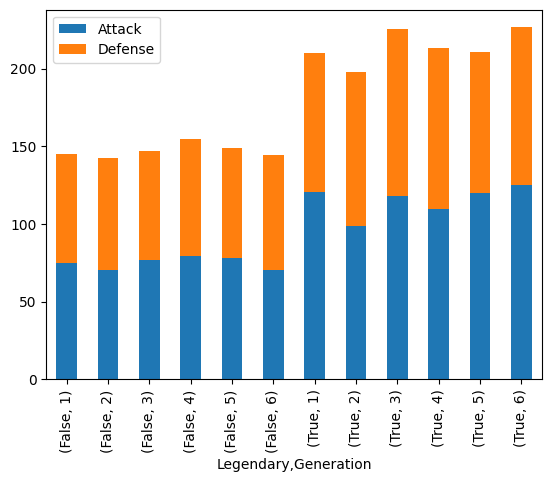

In [ ]:

pkm_stats_legendary.plot.bar(stacked=True)

In [ ]:
# Generamos otro dataset
pkm_stats_by_generation = pkm.groupby('Generation').mean(numeric_only=True)[['HP', 'Attack', 'Defense',
       'Sp. Atk', 'Sp. Def', 'Speed']]
pkm_stats_by_generation

,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
Generation,,,,,,
1,65.819277,76.638554,70.861446,71.819277,69.090361,72.584337
2,71.207547,72.028302,73.386792,65.943396,73.905660,61.811321
3,66.543750,81.625000,74.100000,75.806250,71.225000,66.925000
4,73.082645,82.867769,78.132231,76.404959,77.190083,71.338843
5,71.787879,82.066667,72.327273,71.987879,68.739394,68.078788
6,68.268293,75.804878,76.682927,74.292683,74.890244,66.439024


<Axes: xlabel='Generation'>

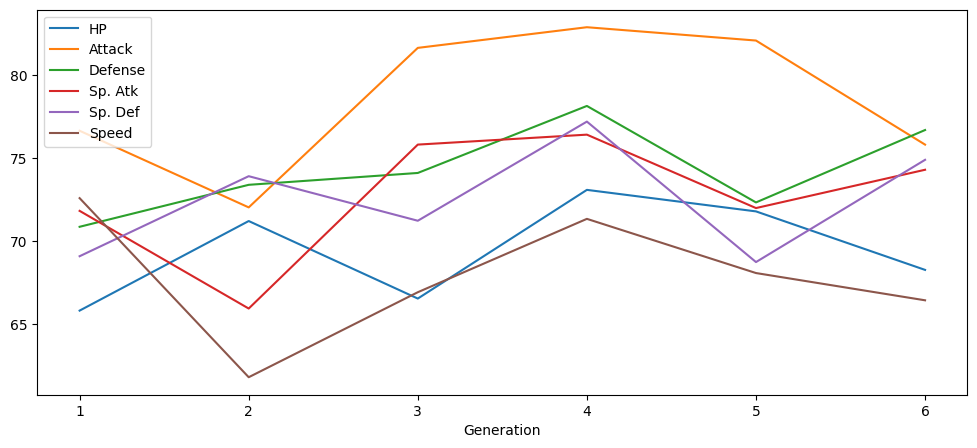

In [ ]:
pkm_stats_by_generation.plot.line(figsize=(12,5))
# Analizar variable ordinal vs numericas

In [ ]:
#Coef. Corr. Pearson
pkm.select_dtypes(include=['number']).corr().round(3)

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
Total,1.000,0.619,0.736,0.613,0.747,0.718,0.576,0.048
HP,0.619,1.000,0.422,0.240,0.362,0.379,0.176,0.059
Attack,0.736,0.422,1.000,0.439,0.396,0.264,0.381,0.051
Defense,0.613,0.240,0.439,1.000,0.224,0.511,0.015,0.042
Sp. Atk,0.747,0.362,0.396,0.224,1.000,0.506,0.473,0.036
Sp. Def,0.718,0.379,0.264,0.511,0.506,1.000,0.259,0.028
Speed,0.576,0.176,0.381,0.015,0.473,0.259,1.000,-0.023
Generation,0.048,0.059,0.051,0.042,0.036,0.028,-0.023,1.000


<Axes: >

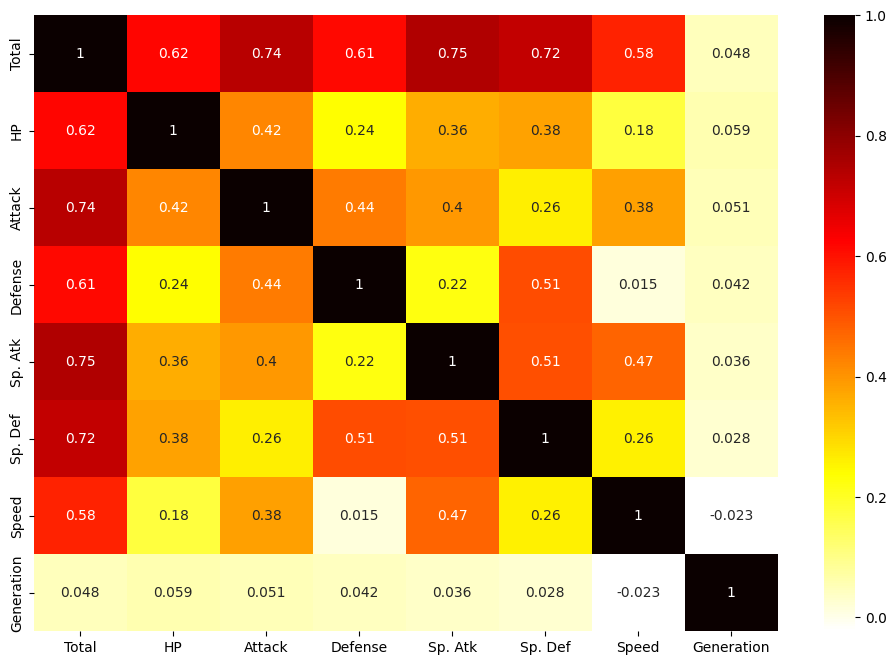

In [ ]:
plt.figure(figsize=(12,8))

pkm_corr = pkm.select_dtypes(include=['number']).corr() # guardamos coef de corr
sns.heatmap(pkm_corr,
            xticklabels=pkm_corr.columns.values,
            yticklabels = pkm_corr.columns.values, annot =True, cmap='hot_r')

In [ ]:
from scipy.stats import pearsonr

pearsonr(pkm['Attack'], pkm['Defense']) # Coef. Pearson, p-value / significance level < 0.05
# Conclusion: podemos confiar en este coeficiente de correlacion

PearsonRResult(statistic=np.float64(0.4386870551184896), pvalue=np.float64(5.8584798642891506e-39))

Otro caso

In [ ]:
vg_path = '/content/drive/MyDrive/Analítica de datos - UF3 /3.2/3.2.1/Datos/Video_Games_Sales_as_at_22_Dec_2016.csv'
vg = pd.read_csv(vg_path)
vg.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
vg.shape

(16719, 16)

In [ ]:
vg.count()

,0
Name,16717
Platform,16719
Year_of_Release,16450
Genre,16717
Publisher,16665
NA_Sales,16719
EU_Sales,16719
JP_Sales,16719
Other_Sales,16719
Global_Sales,16719


In [ ]:
vg.describe().T

,count,mean,std,min,25%,50%,75%,max
Year_of_Release,16450.0,2006.487356,5.878995,1980.00,2003.00,2007.00,2010.00,2020.00
NA_Sales,16719.0,0.263330,0.813514,0.00,0.00,0.08,0.24,41.36
EU_Sales,16719.0,0.145025,0.503283,0.00,0.00,0.02,0.11,28.96
JP_Sales,16719.0,0.077602,0.308818,0.00,0.00,0.00,0.04,10.22
Other_Sales,16719.0,0.047332,0.186710,0.00,0.00,0.01,0.03,10.57
Global_Sales,16719.0,0.533543,1.547935,0.01,0.06,0.17,0.47,82.53
Critic_Score,8137.0,68.967679,13.938165,13.00,60.00,71.00,79.00,98.00
Critic_Count,8137.0,26.360821,18.980495,3.00,12.00,21.00,36.00,113.00
User_Count,7590.0,162.229908,561.282326,4.00,10.00,24.00,81.00,10665.00


In [2]:
# Data profiling
import numpy as np

#profile = ProfileReport(vg, title="Profiling Report")
#profile.to_notebook_iframe()

In [ ]:
# Categoricas vs categoricas
# Cross Tabulation
pd.crosstab(vg['Genre'], vg['Rating'])

Rating,AO,E,E10+,EC,K-A,M,RP,T
Genre,,,,,,,,
Action,1,416,481,1,0,608,0,681
Adventure,0,162,68,2,0,99,0,115
Fighting,0,8,19,0,0,49,0,362
Misc,0,457,167,5,1,13,0,239
Platform,0,358,144,0,0,3,0,64
Puzzle,0,289,43,0,0,0,0,10
Racing,0,585,96,0,0,18,1,172
Role-Playing,0,84,111,0,0,162,0,420
Shooter,0,48,58,0,0,565,0,348


In [ ]:
pd.crosstab(vg['Genre'], vg['Rating'], normalize=True)

Rating,AO,E,E10+,EC,K-A,M,RP,T
Genre,,,,,,,,
Action,0.000101,0.041809,0.048342,0.000101,0.000000,0.061106,0.000000,0.068442
Adventure,0.000000,0.016281,0.006834,0.000201,0.000000,0.009950,0.000000,0.011558
Fighting,0.000000,0.000804,0.001910,0.000000,0.000000,0.004925,0.000000,0.036382
Misc,0.000000,0.045930,0.016784,0.000503,0.000101,0.001307,0.000000,0.024020
Platform,0.000000,0.035980,0.014472,0.000000,0.000000,0.000302,0.000000,0.006432
Puzzle,0.000000,0.029045,0.004322,0.000000,0.000000,0.000000,0.000000,0.001005
Racing,0.000000,0.058794,0.009648,0.000000,0.000000,0.001809,0.000101,0.017286
Role-Playing,0.000000,0.008442,0.011156,0.000000,0.000000,0.016281,0.000000,0.042211
Shooter,0.000000,0.004824,0.005829,0.000000,0.000000,0.056784,0.000000,0.034975


In [ ]:
# Numerica vs categorica
vg.groupby('Genre')['Global_Sales'].mean()

,Global_Sales
Genre,
Action,0.517884
Adventure,0.182417
Fighting,0.527067
Misc,0.458960
Platform,0.932523
Puzzle,0.419000
Racing,0.583587
Role-Playing,0.622933
Shooter,0.795873


In [ ]:
# Ordenamos generos por ventas mundiales
vg.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)

,Global_Sales
Genre,
Platform,0.932523
Shooter,0.795873
Role-Playing,0.622933
Racing,0.583587
Sports,0.567291
Fighting,0.527067
Action,0.517884
Misc,0.458960
Simulation,0.446705


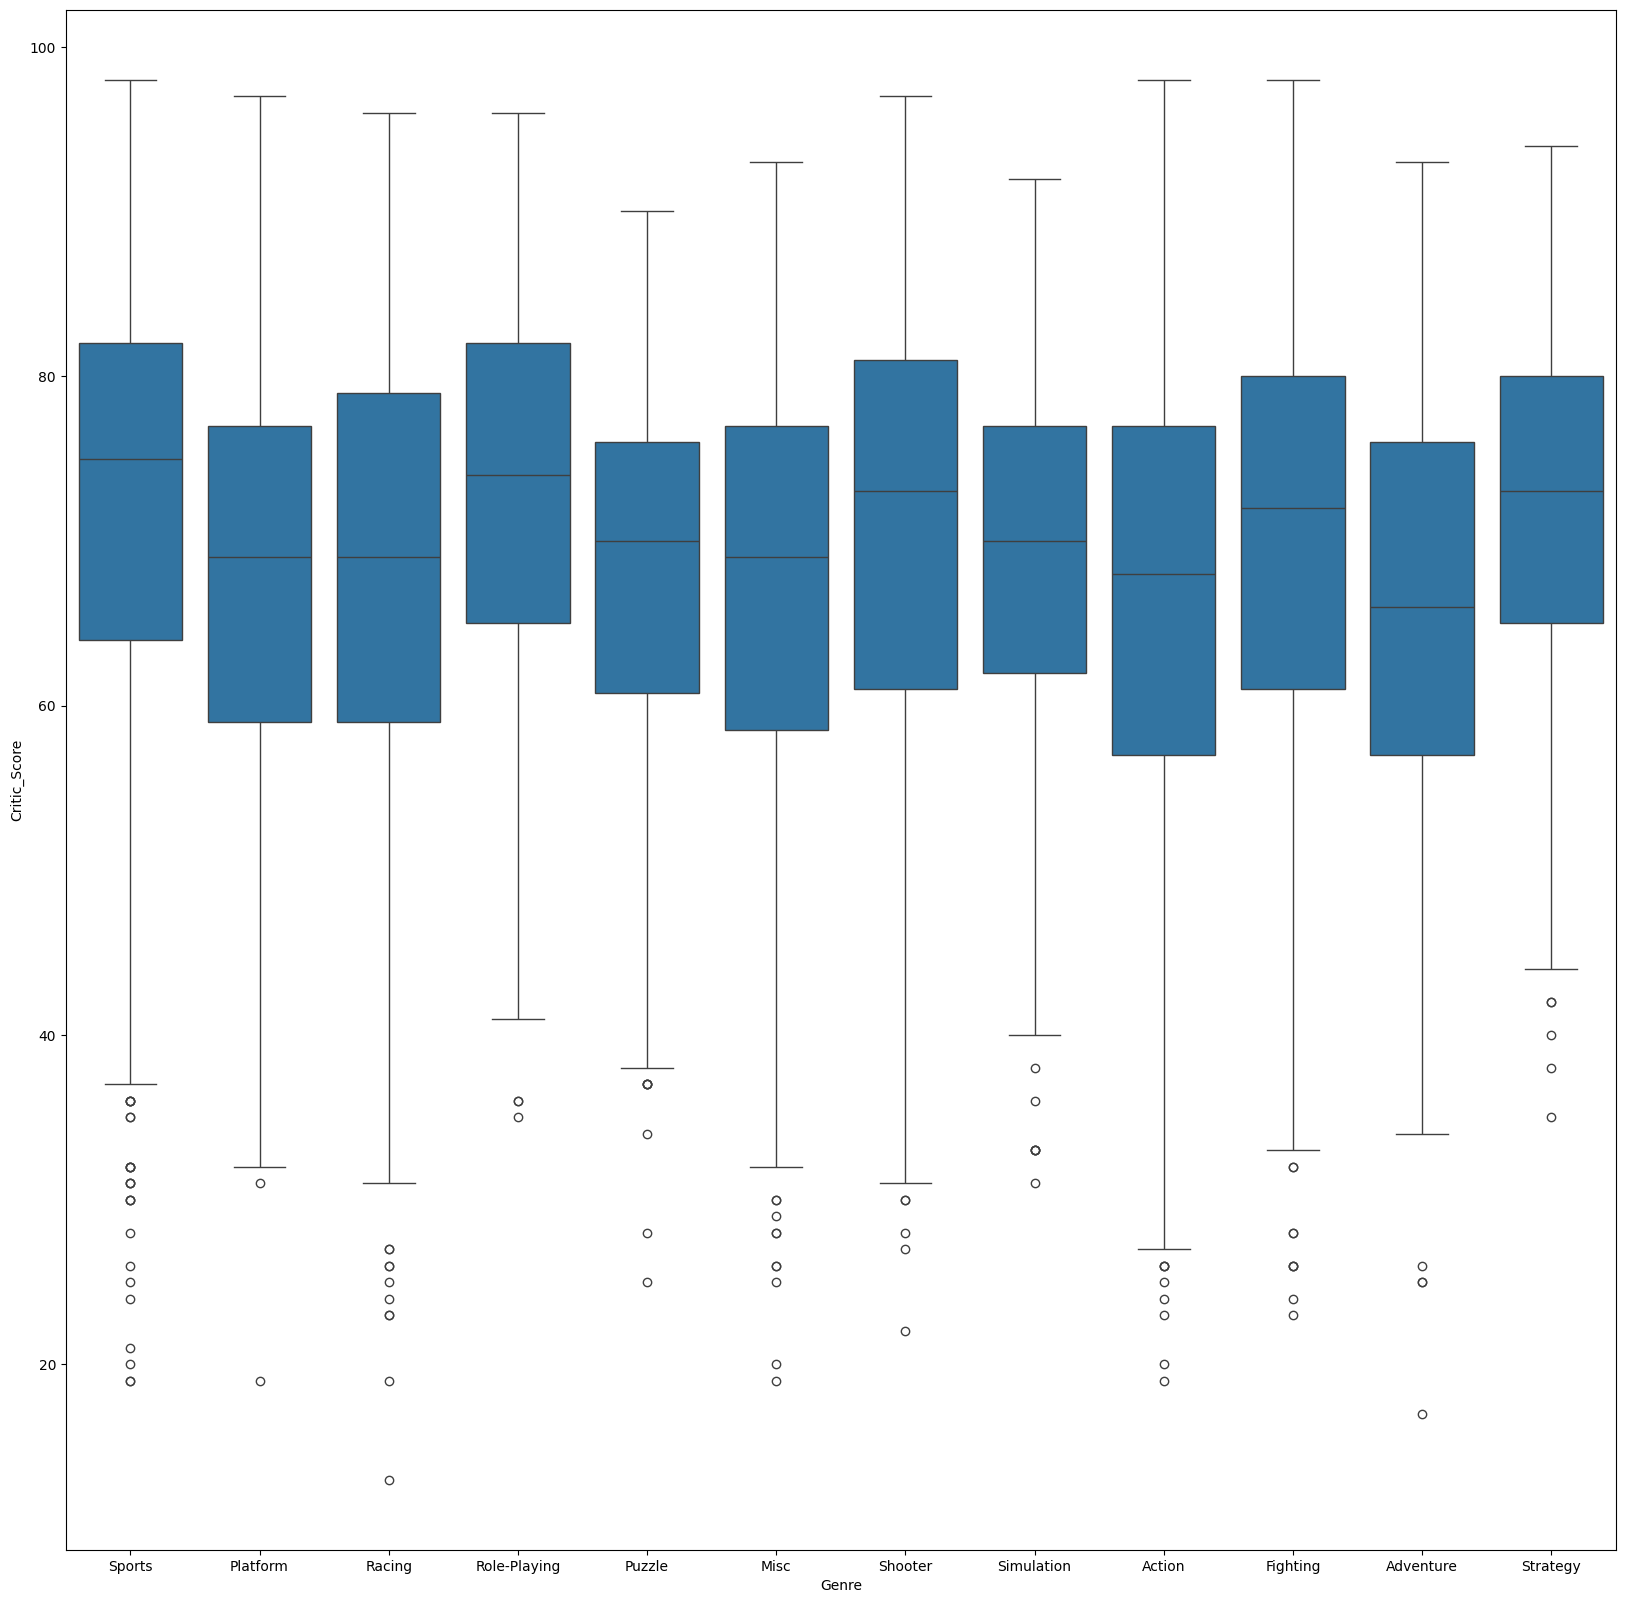

In [ ]:
# Visualizacion de Categorica vs Numerica
plt.figure(figsize=(20,20))
sns.boxplot(y = 'Critic_Score', x='Genre', data=vg)
plt.show()